In [2]:
import pandas as pd
import numpy as np

In [21]:
import pandas as pd
import seaborn as sns

In [22]:
#https://www.kaggle.com/datasets/sonalshinde123/student-placement-dataset
from pandas import read_csv
df=read_csv("C:\\Users\\Varshith\\OneDrive\\Desktop\\KLH\\2year\\Machine Learning\\Placement-Prediction-System\\data\\placement_predict_50k Dataset_final.csv")

In [23]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']
Categorical Features: ['CollegeTier', 'CGPA_Tier']


C:\Users\Varshith\AppData\Local\Temp\ipykernel_27936\1869842994.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [24]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [25]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                            StudentID  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  \
StudentID                    1.000000  -0.007974  -0.003863  -0.006449   
SGPA_Sem1                   -0.007974   1.000000   0.963716   0.963482   
SGPA_Sem2                   -0.003863   0.963716   1.000000   0.964495   
SGPA_Sem3                   -0.006449   0.963482   0.964495   1.000000   
SGPA_Sem4                   -0.000553   0.964156   0.964954   0.965455   
SGPA_Sem5                   -0.002305   0.962643   0.964102   0.964510   
SGPA_Sem6                   -0.002280   0.962483   0.963664   0.965305   
SGPA_Sem7                   -0.002096   0.961956   0.963334   0.965538   
SGPA_Sem8                   -0.003617   0.960569   0.961918   0.965508   
CGPA                        -0.009461   0.910142   0.912600   0.913073   
AttendancePercent            0.005341   0.496515   0.505818   0.515610   
Internships                  0.000923   0.437170   0.448905   0.452541   
Projects  

# Correlation Heatmap

To identify the relationship among numerical features and understand which variables are positively or negatively correlated before model development.
A correlation heatmap visualizes the Pearson correlation coefficient between numerical features.

The correlation coefficient (r) ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Generally,

- **0.70 to 1.00** → Strong positive correlation
- **0.40 to 0.69** → Moderate positive correlation
- **0.00 to 0.39** → Weak positive correlation
- **-0.40 to -0.69** → Moderate negative correlation
- **-0.70 to -1.00** → Strong negative correlation

##Example:

# **1. Coding Skills vs Certifications = 0.86**
Observation
-A strong positive relationship exists.
-Students with better coding skills usually earn more certifications.
-Certifications appear to reflect technical competency.


# 2. Student_ID, Correlation ≈ 0
Observation

- It has no relationship with placement or academic performance.
- It should be removed before model training.

#3.CGPA vs Backlogs = -0.58
    -As CGPA increases, the number of backlogs generally decreases.

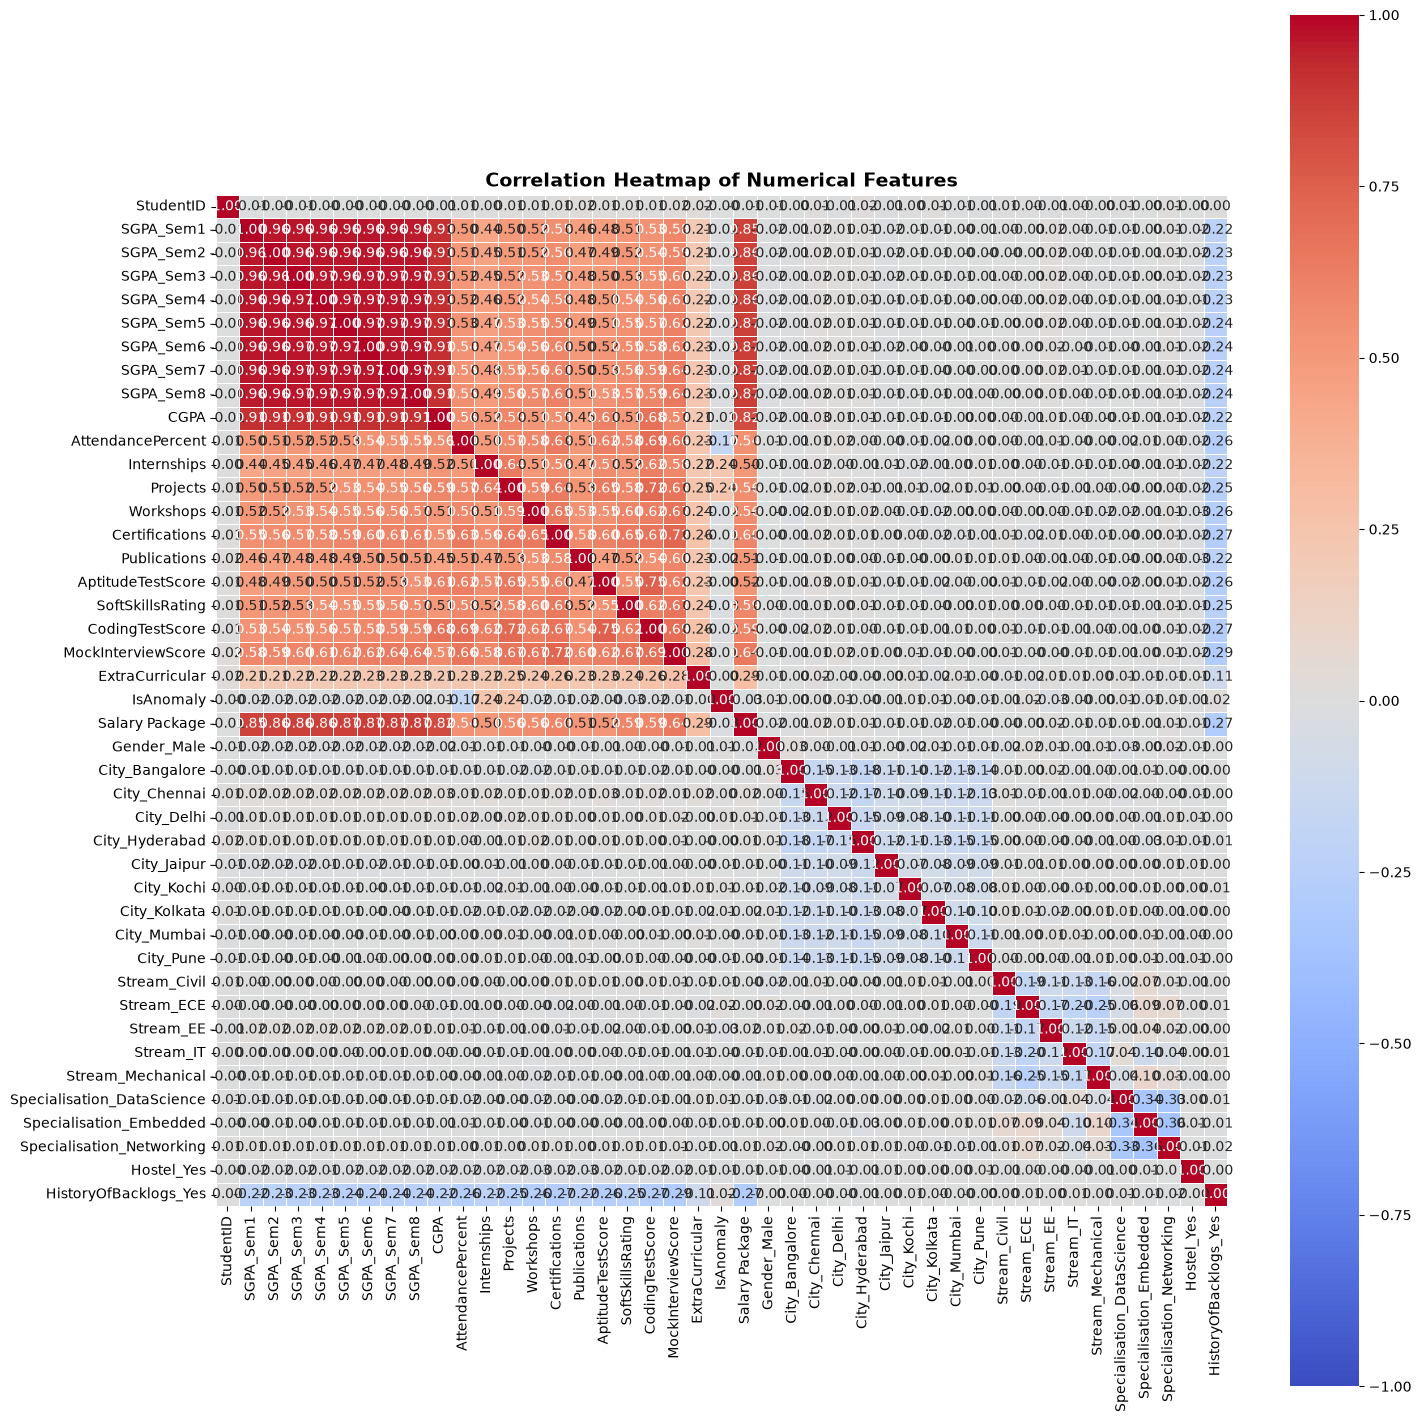

In [26]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [27]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create Heatmap
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features",
          fontsize=14, fontweight='bold')
plt.tight_layout()

# Save inside project/output folder
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")

plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Exported heatmap to: {heatmap_path}")


Exported heatmap to: outputs\correlation_heatmap.png


In [28]:

print(os.getcwd())

c:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\notebooks


In [33]:
# # -------------------------------------------------------------
# # 3. Produce Boxplots: Numerical Features vs PlacementStatus
# # -------------------------------------------------------------
# target_col = "PlacementStatus"
# if target_col in df.columns:
#     for col in numerical_cols:
#         plt.figure(figsize=(6, 5))
#         sns.boxplot(
#             x=target_col,
#             y=col,
#             data=df,
#             palette="Set2",
#             hue=target_col,
#             legend=False
#         )
#         plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
#         plt.xlabel(target_col)
#         plt.ylabel(col)
#         plt.tight_layout()
        

#         # Save the boxplot
#         boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

#         # Create complete file path
#         boxplot_path = os.path.join(output_dir, boxplot_filename)

#         # Save the figure
#         plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

#         # Close the figure
#         plt.close()

#         # Display confirmation message
#         print(f"Exported boxplot to: {boxplot_path}")

#     else:
#         print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

#         print("\nAll EDA tasks completed successfully!")
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
# Export Heatmap
import os

# Define relative output directory and ensure it exists
output_dir = r"../outputs"
os.makedirs(output_dir, exist_ok=True)

heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Exported heatmap to: {heatmap_path}")


Exported heatmap to: ../outputs\correlation_heatmap.png


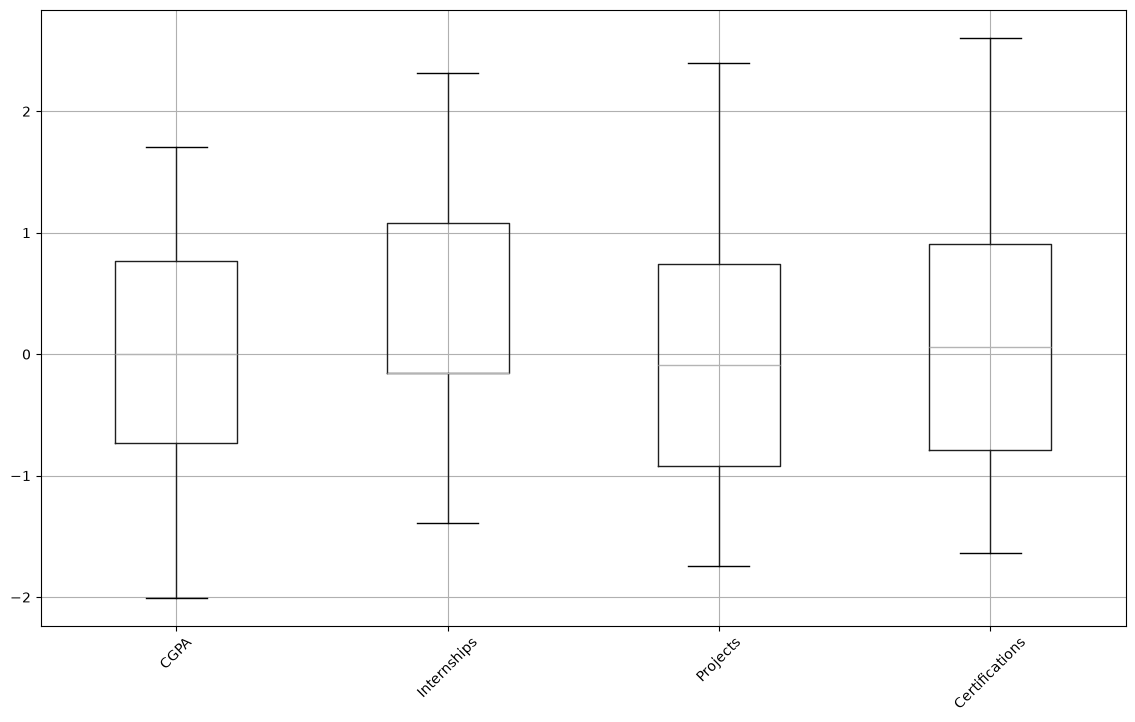

In [35]:
# List of potential numerical columns
potential_cols = [
    "Age", "CGPA", "Internships", "Projects", 
    "Coding_Skills", "Communication_Skills", 
    "Aptitude_Test_Score", "Soft_Skills_Rating", 
    "Certifications", "Backlogs"
]

# Select only numeric columns that exist in df
numerical_columns = [col for col in potential_cols if col in df.columns]

# If no specific columns matched, grab all numeric columns automatically
if not numerical_columns:
    numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

fig6 = plt.figure(figsize=(14, 8))
df[numerical_columns].boxplot()

plt.xticks(rotation=45)
plt.show()

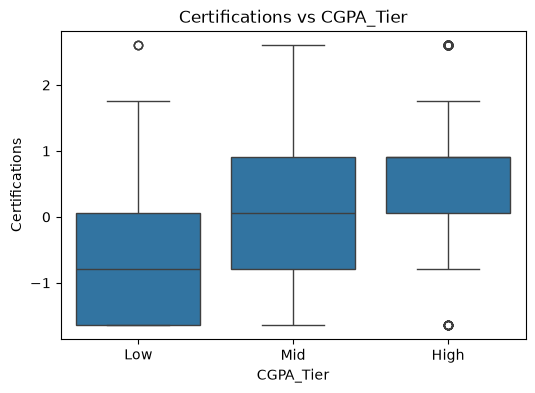

In [39]:
# fig7= sns.boxplot(x='Placement_Status', y='Certifications', data=df)
import matplotlib.pyplot as plt
import seaborn as sns

# Detect which target column is present in df
target_col = next((col for col in ['PlacementStatus', 'CGPA_Tier', 'Placement_Status'] if col in df.columns), None)

if target_col and 'Certifications' in df.columns:
    plt.figure(figsize=(6, 4))
    fig7 = sns.boxplot(x=target_col, y='Certifications', data=df)
    plt.title(f"Certifications vs {target_col}")
    plt.show()
else:
    print(f"Cannot plot: Required columns not found. Available columns are: {list(df.columns)}")

In [42]:
import os
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Define relative output path and ensure the folder exists
output_dir = r"../outputs"
os.makedirs(output_dir, exist_ok=True)
pdf_path = os.path.join(output_dir, "EDA_Report.pdf")

# Get all current active figures created in the notebook
figs = [plt.figure(n) for n in plt.get_fignums()]

if figs:
    with PdfPages(pdf_path) as pdf:
        for fig in figs:
            pdf.savefig(fig, bbox_inches='tight')
    print(f"EDA Report saved successfully to: {pdf_path}")
else:
    print("No active figures found. Make sure to re-run your plotting cells before saving!")

No active figures found. Make sure to re-run your plotting cells before saving!


In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Ensure output directory exists
output_dir = r"../outputs"
os.makedirs(output_dir, exist_ok=True)
pdf_path = os.path.join(output_dir, "EDA_Report.pdf")

# Detect columns dynamically from df
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

with PdfPages(pdf_path) as pdf:

    #------------------------------------------------------
    # Page 1 : Missing Value Heatmap
    #------------------------------------------------------
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis")
    plt.title("Missing Value Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Samples")
    pdf.savefig(bbox_inches='tight')
    plt.close()

    #------------------------------------------------------
    # Page 2 : Histograms (Available Numerical Features)
    #------------------------------------------------------
    if num_cols:
        plot_num = num_cols[:6]
        n_plots = len(plot_num)
        rows = int(np.ceil(n_plots / 2))
        
        fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
        axes = np.array(axes).flatten()

        for i, col in enumerate(plot_num):
            axes[i].hist(df[col].dropna(), bins=15, edgecolor='black')
            axes[i].set_title(f"Histogram of {col}")

        # Hide unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        pdf.savefig(bbox_inches='tight')
        plt.close()

    #------------------------------------------------------
    # Page 3 : Categorical Distribution / Placement Status
    #------------------------------------------------------
    if cat_cols:
        plt.figure(figsize=(10, 6))
        target_cat = cat_cols[0]
        sns.countplot(data=df, x=target_cat)
        plt.title(f"Distribution of {target_cat}")
        plt.xticks(rotation=45)
        pdf.savefig(bbox_inches='tight')
        plt.close()

    #------------------------------------------------------
    # Page 4 : Correlation Heatmap
    #------------------------------------------------------
    if len(num_cols) > 1:
        plt.figure(figsize=(10, 8))
        corr = df[num_cols].corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation Heatmap")
        pdf.savefig(bbox_inches='tight')
        plt.close()

    #------------------------------------------------------
    # Page 5 : Boxplots (Numerical Features)
    #------------------------------------------------------
    if num_cols:
        plot_num = num_cols[:6]
        n_plots = len(plot_num)
        rows = int(np.ceil(n_plots / 2))

        fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
        axes = np.array(axes).flatten()

        for i, col in enumerate(plot_num):
            sns.boxplot(y=df[col], ax=axes[i])
            axes[i].set_title(f"Boxplot of {col}")

        # Hide unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        pdf.savefig(bbox_inches='tight')
        plt.close()

print(f"EDA_Report.pdf created successfully at: {os.path.abspath(pdf_path)}")

C:\Users\Varshith\AppData\Local\Temp\ipykernel_27936\2074594812.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


EDA_Report.pdf created successfully at: c:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\outputs\EDA_Report.pdf
